# Trabajo 01, Parte uno: Optimización heurística

**Subject:** Redes neuronales y algoritmos bioinspirados

**Profesor**: Juan David Ospina Arango

**Monitor**: Andrés Mauricio Zapata

**Author:** Carlos Daniel Urresty Ascuntar,

**Date:** Jun 2026

**Universidad Nacional de Colombia**

**Departamento de Ciencias de la Computación y de la Decisión**

**Semestre 2026-01**

## 1. Optimización por Descenso del Gradiente

#### 1.1.   Librerías y Tipado



In [ ]:
# Módulos
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation  # Animaciones auxiliares

# Tipos
from numpy.typing import NDArray
from typing import Callable, TypedDict
type Array = NDArray[np.float64]
class Configuration(TypedDict):
    rate: float
    max_iterations: int
    initial_position: Array
    function: Callable[[Array], float]
    gradient_function: Callable[[Array], Array]

### 1.2. Algoritmo

In [ ]:
LIMITS = (-5.0, 5.0)
"""
Los límites `a` y `b` para la región [a, b]² donde se genera la posición
inicial.
"""

def get_initial_position(size: int):
    """Genera un arreglo de números aleatorios.

    Los valores del arreglo tienen distribución uniforme con limites dados por
    `LIMITS`.
    """
    return np.random.uniform(*LIMITS, size)

def descend(
        position: Array,
        gradient_function: Callable[[Array], Array],
        rate: float
):
    """Genera una mejor posición descendiendo desde la posición actual.

    Para determinar la nueva posición, se evalúa `gradient_function` en
    `position`, y se toma un paso en la dirección opuesta del gradiente
    obtenido, con su magnitud escalada por `rate`.

    Se retorna `(p_n, g, c)`, donde `p_n` es la nueva posición, `g` es el
    gradiente calculado y `c` es el paso tomado.
    """
    gradient = gradient_function(position)
    change = -rate * gradient
    return position + change, gradient, change

def run(
        initial_position: Array,
        function: Callable[[Array], float],
        gradient_function: Callable[[Array], Array],
        rate: float,
        max_iterations: int
):
    """Implementación del algoritmo del descenso del gradiente.

    De manera repetida, evalúa el gradiente en un punto y desciende haciendo
    uso de la función `descend` hasta alcanzar el máximo de iteraciones."""
    position = initial_position
    print('Posición Inicial:', position)
    print('Valor Función Objetivo:', function(position), '\n')

    for i in range(max_iterations):
        position, gradient, change = descend(
            position, gradient_function, rate
        )
        print('Iteración', i + 1)
        print(f'\t{gradient=}')
        print(f'\t{change=}')
        print(f'\t{position=}')

    print('\nPosición Final:', position)
    print('Valor Función Objetivo:', function(position))

# Animación auxiliar para casos 2D
def plot_animation(
        samples: int,
        function: Callable[[Array, Array], Array],
        curves: int,
        configuration: Configuration,
        output_name: str,
        duration: float = 5,
):
    """Genera una animación del cambio de la solución sobre las curvas de nivel.

    Se genera una cuadrícula de puntos con `samples` puntos de muestra sobre
    ambos ejes coordenados, a partir de la cual se grafican las curvas de nivel
    de la función especificada (usando `num_curves` curvas), y se anima el
    cambio del punto solución a lo largo del tiempo con los parámetros dados en
    `configuration`. La animación
    resultante se guarda en el directorio actual como un video mp4 de `duration`
    segundos con el nombre `output_name`."""
    X, Y = np.meshgrid(*([np.linspace(*LIMITS, samples)]*2))
    fig, ax = plt.subplots()
    ax.contour(X, Y, function(X, Y), curves)
    point = ax.plot(*configuration['initial_position'], 'ro')[0]

    def update(_):
        """Actualiza un punto graficado usando el gradiente descendiente.

        Obtiene el punto actual en el gráfico creado y aplica una iteración
        del algoritmo para retornar el punto del siguiente frame.
        """
        point.set_data(*descend(
            np.array(point.get_data()),
            configuration['gradient_function'],
            configuration['rate']
        )[0])
        return [point]

    anim = animation.FuncAnimation(
        fig,
        func=update,
        frames=configuration['max_iterations'],
        interval=(
            1000*duration / configuration['max_iterations']
        )
    )

    anim.save(output_name)

### 1.3. Función de Rosenbrock

La [función generalizada de Rosenbrock](https://docs.scipy.org/doc/scipy-0.14.0/reference/tutorial/optimize.html#unconstrained-minimization-of-multivariate-scalar-functions-minimize) se expresa como $
f(\mathbf{x}) = \sum _{i=1}^{N-1}\left( 100\left( x_{i} -x_{i-1}^{2}\right)^{2} +( 1-x_{i-1})^{2}\right)
$.

Obtenemos una expresión para el i-ésimo componente del gradiente de Rosenbrock $\nabla f(\mathbf{x})$ por casos:

$$\begin{aligned}
\frac{\partial f(\mathbf{x})}{\partial x_{0}} & =\frac{\partial }{\partial x_{0}}\left( 100\left( x_{1} -x_{0}^{2}\right)^{2} +( 1-x_{0})^{2} +\cdots \right)\\
 & =-400x_{0}\left( x_{1} -x_{0}^{2}\right) -2( 1-x_{0})
\end{aligned} \tag{1}$$

$$\begin{aligned}
\frac{\partial f(\mathbf{x})}{\partial x_{N-1}} & =\frac{\partial }{\partial x_{N-1}}\left( \cdots +100\left( x_{N-1} -x_{N-2}^{2}\right)^{2} +( 1-x_{N-2})^{2}\right)\\
 & =200\left( x_{N-1} -x_{N-2}^{2}\right)
\end{aligned} \tag{2}$$

$$\begin{aligned}
\forall k\in \{1,2,\dotsc ,N-2\} ,\frac{\partial f(\mathbf{x})}{\partial x_{k}} & =\frac{\partial }{\partial x_{k}}\sum _{i=1}^{N-1}\left( 100\left( x_{i} -x_{i-1}^{2}\right)^{2} +( 1-x_{i-1})^{2}\right)\\
 & \begin{align*}
=\frac{\partial }{\partial x_{k}}\Bigl[ \cdots + & \left( 100\left( x_{k} -x_{k-1}^{2}\right)^{2} +( 1-x_{k-1})^{2}\right) +\\
 & \left( 100\left( x_{k+1} -x_{k}^{2}\right)^{2} +( 1-x_{k})^{2}\right) +\cdots \Bigr]
\end{align*}\\
 & =200\left( x_{k} -x_{k-1}^{2}\right) -400x_{k}\left( x_{k+1} -x_{k}^{2}\right) -2( 1-x_{k})\\
 & =400x_{k}^{3} +( 202-400x_{k+1}) x_{k} -200x_{k-1}^{2} -2
\end{aligned} \tag{3}$$

Así, para el caso de 2 variables, utilizamos $\begin{cases}
N = 2, \\
x_0 = x, \\
x_1 = y,
\end{cases}$ donde no aplicaría $(3)$, y para 3 variables, $\begin{cases}
N = 3, \\
x_0 = x, \\
x_1 = y, \\
x_2 = z.
\end{cases}$

In [ ]:
def rosenbrock(x: Array):
    """Calcula la función de rosenbrock en un punto x con `N` dimensiones."""
    N = len(x)
    return sum(
        100 * (x[i] - x[i-1]**2)**2 + (1 - x[i-1])**2
        for i in range(1, N)
    )

def rosenbrock_gradient(x: Array):
    """Calcula el gradiente de rosenbrock en un punto x con `N` dimensiones."""
    N = len(x)
    return np.array([
        -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0]) if k == 0 else
        200 * (x[N-1] - x[N-2]**2) if k == N-1 else
        400*x[k] + (202 - 400*x[k+1])*x[k] - 200*x[k-1]**2 - 2
        for k in range(N)
    ])

#### 1.3.1 2D

#### 1.3.2 Optimización

In [ ]:
rosenbrock_2d_configuration: Configuration = {
    'rate': 0.0001,
    'max_iterations': 1000,
    'initial_position': get_initial_position(2),
    'function': rosenbrock,
    'gradient_function': rosenbrock_gradient,
}

run(**rosenbrock_2d_configuration)

Posición Inicial: [ 3.14670805 -2.23757945]
Valor Función Objetivo: 14740.992594755146 

Iteración 1
	gradient=array([15283.89079573, -2427.87019746])
	change=array([-1.52838908,  0.24278702])
	position=array([ 1.61831897, -1.99479243])
Iteración 2
	gradient=array([2987.84346027, -922.74974237])
	change=array([-0.29878435,  0.09227497])
	position=array([ 1.31953462, -1.90251745])
Iteración 3
	gradient=array([1923.82862365, -728.73781475])
	change=array([-0.19238286,  0.07287378])
	position=array([ 1.12715176, -1.82964367])
Iteración 4
	gradient=array([1397.97422794, -620.02295254])
	change=array([-0.13979742,  0.0620023 ])
	position=array([ 0.98735434, -1.76764138])
Iteración 5
	gradient=array([1083.10635204, -548.50199292])
	change=array([-0.10831064,  0.0548502 ])
	position=array([ 0.8790437 , -1.71279118])
Iteración 6
	gradient=array([ 873.70650336, -497.10180162])
	change=array([-0.08737065,  0.04971018])
	position=array([ 0.79167305, -1.663081  ])
Iteración 7
	gradient=array([ 724

#### 1.3.3 Animación Auxiliar

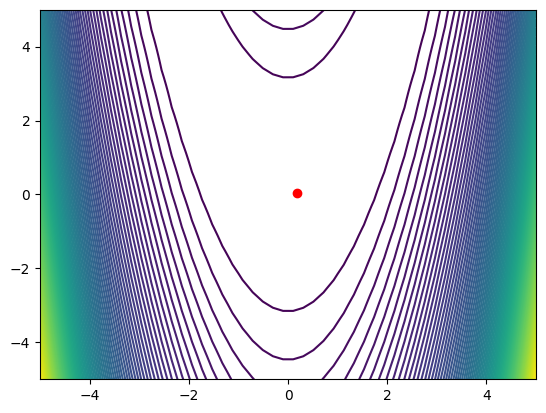

In [ ]:
plot_animation(
    samples=50,
    function=lambda X, Y: 100*(Y - X**2)**2 + (1 - X)**2,
    curves=100,
    configuration=rosenbrock_2d_configuration,
    output_name='rosen_2d_grad.mp4'
)

#### 1.3.4 3D

In [ ]:
rosenbrock_3d_configuration = {
    'initial_position': get_initial_position(3),
    'rate': 0.000_1,
    'max_iterations': 10_000,
    'function': rosenbrock,
    'gradient_function': rosenbrock_gradient
}

run(**rosenbrock_3d_configuration)

Posición Inicial: [-1.8303163  -0.09521507  3.46711906]
Valor Función Objetivo: 2392.0138349428407 

Iteración 1
	gradient=array([-2528.03624862,  -597.28223386,   691.61062942])
	change=array([ 0.25280362,  0.05972822, -0.06916106])
	position=array([-1.57751268, -0.03548684,  3.39795799])
Iteración 2
	gradient=array([-1597.83270733,  -472.83920729,   679.33973544])
	change=array([ 0.15978327,  0.04728392, -0.06793397])
	position=array([-1.41772941,  0.01179708,  3.33002402])
Iteración 3
	gradient=array([-1137.97530664,  -412.60331327,   665.97696976])
	change=array([ 0.11379753,  0.04126033, -0.0665977 ])
	position=array([-1.30393188,  0.05305741,  3.26342632])
Iteración 4
	gradient=array([-863.73255286, -379.36668443,  652.12224687])
	change=array([ 0.08637326,  0.03793667, -0.06521222])
	position=array([-1.21755862,  0.09099408,  3.1982141 ])
Iteración 5
	gradient=array([-682.10629101, -360.11878005,  637.98683526])
	change=array([ 0.06821063,  0.03601188, -0.06379868])
	position=ar

/tmp/ipykernel_565/3708691700.py:13: RuntimeWarning: overflow encountered in scalar power
  -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0]) if k == 0 else
/tmp/ipykernel_565/3708691700.py:15: RuntimeWarning: overflow encountered in scalar power
  400*x[k] + (202 - 400*x[k+1])*x[k] - 200*x[k-1]**2 - 2
/tmp/ipykernel_565/3708691700.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0]) if k == 0 else
/tmp/ipykernel_565/3708691700.py:15: RuntimeWarning: invalid value encountered in scalar add
  400*x[k] + (202 - 400*x[k+1])*x[k] - 200*x[k-1]**2 - 2


Streaming output truncated to the last 5000 lines.
	position=array([nan, nan, nan])
Iteración 8752
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8753
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8754
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8755
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8756
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8757
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8758
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8759
	gradient=array([nan, nan, nan])
	change=array([nan, nan, nan])
	position=array([nan, nan, nan])
Iteración 8760
	grad

### 1.4. Función de Schwefel

$$f(\mathbf{x}) =418.9829d-\sum _{i=1}^{d} x_{i}\sin{\sqrt{|x_{i}|}}$$

$$\begin{aligned}
    \frac{\partial f}{\partial x_{k}} & = \frac{\partial }{\partial x_{k}}
        \left( -\sum _{i=1}^{d} x_{i}\sin{\sqrt{|x_{i}|}}\right) \\
    & = -\frac{\partial}{\partial x_{k}} x_{k} \sin{\sqrt{|x_{k}|}} \\
    & = -x_{k}\frac{\partial }{\partial x_{k}}
        \left(\sin{\sqrt{|x_{k}|}}\right) -\sin{\sqrt{|x_{k}|}} \\
    & \begin{array}{l}
        =-\frac{\cos{\sqrt{|x_{k}|}}}{2 \sqrt{|x_{k}|}} s_{k} x_{k}
            - \sin{\sqrt{|x_{k}|}} \\
    \end{array}
\end{aligned}$$

donde $s_{k} = \frac{\partial}{\partial x_{k}} |x_{k}| = \begin{cases}
    1, & x > 0,\\
    -1, & x < 0.
\end{cases}$

Algo a resaltar (y el divisor $2 \sqrt{|x_k|}$ lo hace evidente) es que esta
derivación no es válida para $x_k = 0$. Si bien esto no nos preocupa para la
implementación del algoritmo (pues es altamente improbable obtener una
coordenada exactamente igual a 0), sí indica que el proceso de optimización
puede ser problemático si en algún momento nos encontramos cerca de las rectas
$x = 0$ y $y = 0$.

In [ ]:
def schwefel(x: Array):
    d = len(x)
    return 418.9829*d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

def schwefel_gradient(x: Array):
    sq_abs_x = np.sqrt(np.abs(x))
    return -np.cos(sq_abs_x)/(2 * sq_abs_x) - np.sin(sq_abs_x)

#### 1.4.1 2D

#### 1.4.2 Optimización

In [ ]:
schwefel_2d_configuration: Configuration = {
    'initial_position': get_initial_position(2),
    'rate': 0.001,
    'max_iterations': 10_000,
    'function': schwefel,
    'gradient_function': schwefel_gradient
}

run(**schwefel_2d_configuration)

Streaming output truncated to the last 5000 lines.
	position=array([6.93740216, 4.71714582])
Iteración 8752
	gradient=array([-0.32027815, -0.69451478])
	change=array([0.00032028, 0.00069451])
	position=array([6.93772243, 4.71784033])
Iteración 8753
	gradient=array([-0.32022324, -0.69440358])
	change=array([0.00032022, 0.0006944 ])
	position=array([6.93804266, 4.71853474])
Iteración 8754
	gradient=array([-0.32016833, -0.69429239])
	change=array([0.00032017, 0.00069429])
	position=array([6.93836283, 4.71922903])
Iteración 8755
	gradient=array([-0.32011344, -0.69418122])
	change=array([0.00032011, 0.00069418])
	position=array([6.93868294, 4.71992321])
Iteración 8756
	gradient=array([-0.32005856, -0.69407005])
	change=array([0.00032006, 0.00069407])
	position=array([6.939003  , 4.72061728])
Iteración 8757
	gradient=array([-0.32000368, -0.6939589 ])
	change=array([0.00032   , 0.00069396])
	position=array([6.939323  , 4.72131124])
Iteración 8758
	gradient=array([-0.31994882, -0.69384776])
	c

#### 1.4.3 Animación Auxiliar

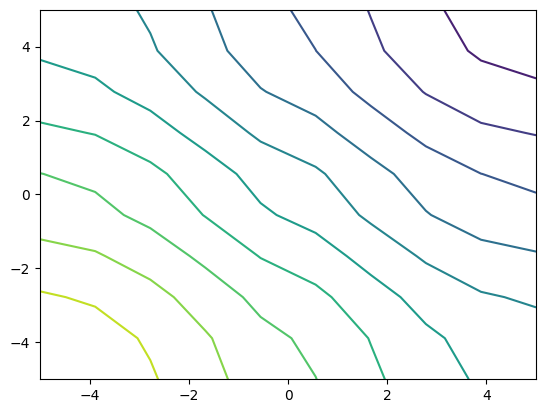

In [ ]:
plot_animation(
    samples=10,
    function=lambda X, Y: 418.9829*2 - X*np.sin(np.sqrt(np.abs(X))) - Y*np.sin(np.sqrt(np.abs(Y))),
    configuration=schwefel_2d_configuration,
    curves=10,
    output_name='schwefel_2d_grad.mp4'
)

#### 1.4.4 3D

In [ ]:
schwefel_2d_configuration = {
    'initial_position': get_initial_position(3),
    'rate': 0.001,
    'max_iterations': 10_000,
    'function': schwefel,
    'gradient_function': schwefel_gradient
}

run(**schwefel_2d_configuration)

Streaming output truncated to the last 5000 lines.
	position=array([6.62630878, 5.94714064, 6.51020329])
Iteración 8752
	gradient=array([-0.37366944, -0.49001658, -0.39360559])
	change=array([0.00037367, 0.00049002, 0.00039361])
	position=array([6.62668245, 5.94763065, 6.5105969 ])
Iteración 8753
	gradient=array([-0.37360527, -0.48993306, -0.39353801])
	change=array([0.00037361, 0.00048993, 0.00039354])
	position=array([6.62705606, 5.94812059, 6.51099043])
Iteración 8754
	gradient=array([-0.37354112, -0.48984955, -0.39347045])
	change=array([0.00037354, 0.00048985, 0.00039347])
	position=array([6.6274296 , 5.94861044, 6.51138391])
Iteración 8755
	gradient=array([-0.37347698, -0.48976605, -0.39340289])
	change=array([0.00037348, 0.00048977, 0.0003934 ])
	position=array([6.62780307, 5.9491002 , 6.51177731])
Iteración 8756
	gradient=array([-0.37341284, -0.48968256, -0.39333535])
	change=array([0.00037341, 0.00048968, 0.00039334])
	position=array([6.62817649, 5.94958988, 6.51217064])
Itera

## 2 Optimización Por Algoritmos Evolutivos

### 2.1. Planteamiento

El objetivo de este notebook es evaluar dos métodos de optimización escojidos por el equipo con el fin de medir su rendimiento. En particular, se utilizarán las funciones de **Rosenbrock** y **Schwefel**. Estas funciones serán optimizadas mediante el método del gradiente descendente y tres algoritmos heurísticos: Algoritmos Evolutivos, Optimización por Enjambre de Partículas y Evolución Diferencial.

Al final, se comentará sobre los aportes de los métodos de descenso por gradiente y los métodos heurísticos, considerando el valor final de la función objetivo y el número de evaluaciones de la función objetivo, en un entorno de simulación con varios parámetros y condiciones para garantizar conclusiones significativas.


#### 2.1.1 Generación de la población inicial
A continuación se muestra como una población inicial $P^{(0)}$ evoluciona para que los individuos que la componen minimicen la funcion $f_{fitness}$, que es una función de valor real.

Se representa por $x^{(t)}_{i} = [x^{(t)}_{i,1},\ldots,x^{(t)}_{i,d}]^T$ la $i$-ésima solución de la población $P^{(t)} \in \mathbb{R}^{n \times d}$.

A continuación se definirá cada uno de los pasos de un algoritmo evolutivo general.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [ ]:
def pob_inicial(N = 30, d = 5,  LB = None, UB = None):

    """Genera una población inicial.

    Parameters
    ----------
    N : int
        Tamaño de la población
    d : int
        Dimensión del problema
    LB : float, vector de dimensión d
        Límite inferior de cada una de las variables del problema
    UB : float, vector de dimensión d
        Límite superior de cada una de las variables del problema

    Returns
    -------
    float
        Matriz de dimensión N (filas) por d (columnas)
    """
    if LB is None:
      LB = - np.ones(d)
    if UB is None:
      UB = np.ones(d)

    Pob_ini = np.random.rand(N, d)


    # Normalización
    Pob_ini = Pob_ini * (UB - LB)  + LB

    return Pob_ini


#### 2.1.2 Operación de mutación

A continuación se muestra la operación de mutación. Si $x^{(t)}_{i} = [x^{(t)}_{i,1},\ldots,x^{(t)}_{i,d}]^T$ es seleccionado para mutar y se decide que mute en la coordenada

In [ ]:
def mutacion(Pob, id_mutantes = None, coord_mut = None, LB = None, UB = None):

  """Genera los individuos mutantes

  Parámetros
  ----------

  Pob: float, matriz
      Cada elemento de la matriz Pob es un individuo que mutará.
  id_mutantes: int, vector
      Índices de los individuos que mutarán. Su dimensión es el número de filas
      de Pob.
  coord_mut: int, vector
      Coordenadas en las que se producirán las mutaciones.
  semilla: int
      Semilla para el generador de números aleatorios.
  """

  Pob = Pob.copy() # Para no afectar la matriz de entrada.

  (n_row, n_col) = Pob.shape

  if id_mutantes is None:
    id_mutantes = range(n_row)

  if coord_mut is None:
    coord_mut = np.random.randint(low = 0, high = n_col, size = n_row)

  if LB is None:
    LB = Pob.min(0) # mínimos de cada columna


  if UB is None:
    UB = Pob.max(0) # máximos de cada columna

  for i in id_mutantes:
    mutacion = np.random.rand() * (UB[coord_mut[i]] - LB[coord_mut[i]]) + LB[coord_mut[i]]
    Pob[i, coord_mut[i]] = mutacion

  return Pob[id_mutantes,:]


#### 2.1.3 Cruzamiento

A continuación se define la función de cruzamiento:

In [ ]:
def cruzamiento(Pob_cruce):

  """Cruzamiento

  Parámetros:
  ----------

  Pob_cruce: float, matriz
          Matriz con los individuos que se cruzarán
  semilla: int
          Semilla para el generador de números aleatorios
  """

  Pob_cruce = Pob_cruce.copy()

  (n_row, n_col) = Pob_cruce.shape

  Pob_hijos = np.zeros_like(Pob_cruce)
  n_cruzamiento = (np.floor(n_row/2)).astype(int)

  for i in range(n_cruzamiento):
    coord_cruzamiento = np.random.randint(low = 0, high = n_col, size = 1)[0]
    Pob_hijos[i,:] = np.concatenate((Pob_cruce[i, :coord_cruzamiento],Pob_cruce[i + n_cruzamiento, coord_cruzamiento:]))
    Pob_hijos[i + n_cruzamiento,:] = np.concatenate((Pob_cruce[i + n_cruzamiento, :coord_cruzamiento],Pob_cruce[i, coord_cruzamiento:]))
  return Pob_hijos




A continuación se define la función que toma una generación de soluciones y a partir de las operaciones genéticas construye la siguiente generación:

In [ ]:
def next_gen(Pob, fr_elitismo = 0.2, fr_mutacion = 0.1, LB = None, UB = None):

  """nex_gen

  Parámetros:
  -----------
  Pob: float, matriz
      Población de partida ordenada por el valor de la función objetivo
  fr_elitismo: float, (entre 0 y 1)
      Porcentaje de elitismo
  fr_mutacion: float, (entre 0 y 1)
      Porcentaje de individuos que muta
  LB: float, vector
      Límite inferior de cada una de las variables de decisión
  UB: float, vector
      Límite superior de cada una de las variables de decisión

  """


  Pob = Pob.copy()
  (n_row, n_col) = Pob.shape

  n_mutacion = (np.floor(n_row * fr_mutacion)).astype(int)
  n_cruzamiento = (2 * np.floor(n_row*(1 - fr_elitismo - fr_mutacion)/2)).astype(int)
  n_elite = n_row - n_mutacion - n_cruzamiento

  # Población élite
  Pob_elite = Pob[:n_elite,]

  # Población cruce
  indices_cruzamiento = np.random.choice(n_row, size=n_cruzamiento, replace=False)
  Pob_cruce = cruzamiento(Pob[indices_cruzamiento,])

  # Población mutante:
  id_mutantes = np.random.randint(low = 0, high = n_col, size = n_mutacion)
  Pob_mutante = mutacion(Pob, id_mutantes = id_mutantes, LB = LB, UB = UB)

  # Nueva población
  Pob_next_gen = np.concatenate((Pob_elite, Pob_cruce, Pob_mutante), axis = 0)
  return (Pob_next_gen)


Evaluación de la población con la función objetivo y ranking de las soluciones:

In [ ]:
def pob_eval(Pob, f_obj):

  """pob_eval

  Parámetros:
  ----------
  Pob: float, matriz
      Población a evaluar. Cada fila es una solución
  f_obj: function
      Función objetivo


  Returns:
  --------
  Pob_ranked: float, matriz
    Población rankeada. La primera fila tiene el mejor valor de la función objetivo (el más bajo)

  f_best: float
    Mejor valor de la función objetivo (el más pequeño)


  """

  Pob = Pob.copy()
  (n_row, n_col) = Pob.shape
  fitness_val = np.zeros((n_row))

  # Evaluación de la función objetivo en la población
  for i in range(n_row):
    fitness_val[i] = f_obj(Pob[i,:])

  # Ranking de las soluciones
  pop_ranking = np.argsort(fitness_val)

  # Extracción del mejor valor en la población
  f_best = fitness_val[pop_ranking[0]]

  return(Pob[pop_ranking], f_best)

Algoritmo evolutivo con todo lo anterior:

In [ ]:
def mi_algoritmo_evolutivo(f_obj, N = 30, d = 3, LB = None, UB = None, fr_elitismo = 0.2, fr_mutacion = 0.10, max_iter = 50, semilla = None):

  """mi_algoritmo_evolutivo

  Parámetros:
  ----------

    f_obj: function
        Función objetivo
    N : int
        Tamaño de la población
    d : int
        Dimensión del problema
    LB : float, vector de dimensión d
        Límite inferior de cada una de las variables del problema
    UB : float, vector de dimensión d
        Límite superior de cada una de las variables del problema
    fr_elitismo: float, (entre 0 y 1)
        Porcentaje de elitismo
    fr_mutacion: float, (entre 0 y 1)
        Porcentaje de individuos que muta
    max_iter: int
        Máximo número de iteraciones
    semilla : int
        Semilla para el generador de números aleatorios


  Returns:
  --------
  Pob: list of floats,
    Población en cada generación

  f_best: float
    Mejor valor de la función objetivo (el más pequeño) en cada generación


  """

  Pob0 = pob_inicial(N = N, d = d,  LB = LB, UB = UB)

  Pob = []
  f_best = []
  Pob.append(Pob0)

  if not semilla is None:
    np.random.seed(semilla)

  #print(np.random.get_state()[1][0])
  for i in range(max_iter):
    Pob_ranked, f_best_gen_i = pob_eval(Pob = Pob[i], f_obj = f_obj)
    f_best.append(f_best_gen_i)
    Pob.append(next_gen(Pob_ranked, fr_elitismo = fr_elitismo, fr_mutacion = fr_mutacion, LB = LB, UB = UB))
  return(Pob,np.array(f_best))



### 2.2. Optimización la función Rosenbrock

A continuación se muestra la optimización de la función de Rosenbrock:
$$f(x) = \sum_{i=1}^{n-1} \left[ 100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$$

In [ ]:
def rosenbrock(x: list[float]):
    N = len(x)
    return sum([
        100 * (x[i] - x[i-1]**2)**2 + (1 - x[i-1])**2
        for i in range(1, N)
    ])

#### 2.2.1 Caso bimodal (Dimensión 2)

Para dos dimensiones la función esta dada por
$$f(x,y) = 100(y - x^2)^2 + (1 - x)^2$$

In [ ]:
# Paso intermedio para graficar las curvas de nivel de la función:
n_points = 50
X = np.linspace(-1,1,n_points)
Y = np.linspace(-1,1,n_points)
X, Y = np.meshgrid(X,Y)

In [ ]:
Z = np.array([
    rosenbrock(np.array([X[i,j], Y[i,j]]))
    for i in range(n_points)
    for j in range(n_points)
]).reshape(n_points, n_points)

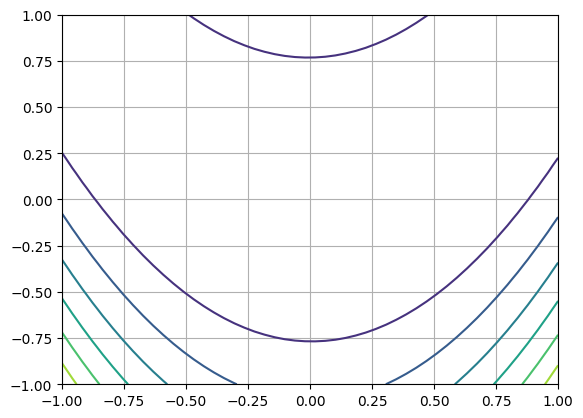

In [ ]:
# Gráfica de las curvas de nivel de la función:
fig, ax = plt.subplots()
ax.contour(X,Y,Z)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.grid()
plt.show()

Optimización de la función

In [ ]:
Poblacion, mejor_solucion = mi_algoritmo_evolutivo(f_obj = rosenbrock, d = 2,fr_elitismo = 0.1, max_iter=100, semilla = 2)

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7,6))

ax.contour(X, Y, Z, levels=20)
scat = ax.scatter([], [], c='red', s=35)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_title("Evolución de la población - Rosenbrock")

def update(frame):
    data = Poblacion[frame]
    scat.set_offsets(data[:, :2])
    ax.set_title(f"Generación {frame}")
    return scat,

anim = FuncAnimation(fig, update, frames=len(Poblacion), interval=200)

# Exportar como MP4
anim.save("rosenbrock_animacion.mp4", writer="ffmpeg", fps=5, dpi=150)

# Opcional: mostrar en notebook
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

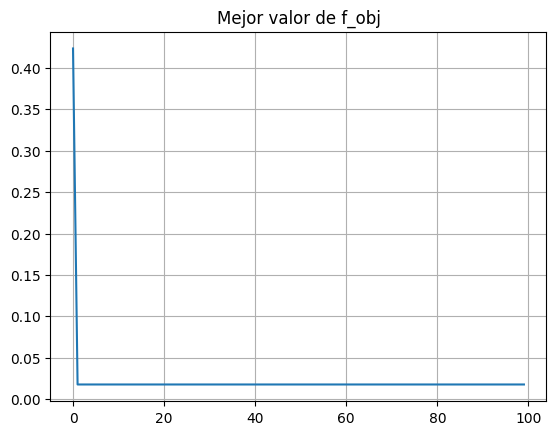

In [ ]:
# Gráfica del valor de la función objetivo de la mejor solución en cada generación.
plt.plot(np.arange(len(mejor_solucion)),mejor_solucion)
plt.title('Mejor valor de f_obj')
plt.grid()
plt.show()

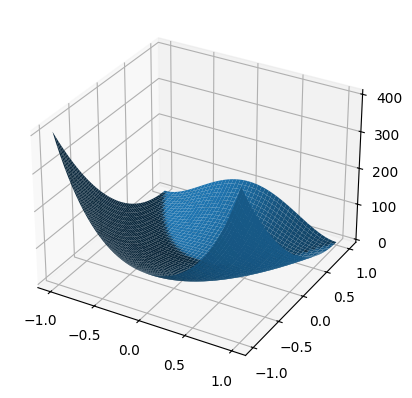

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X,Y,Z)
plt.show()

In [ ]:
# Gráfica del valor de la función objetivo de la mejor solución en cada generación.

"""
for j in range(100):
  fig, ax = plt.subplots()
  ax.contour(X,Y,Z)
  ax.scatter(Poblacion[j][:,0], Poblacion[j][:,1])
  plt.xlim([-1,1])
  plt.ylim([-1,1])
  plt.title('Generación ' + str(j))
  plt.show()

  """

"\nfor j in range(100):\n  fig, ax = plt.subplots()\n  ax.contour(X,Y,Z)\n  ax.scatter(Poblacion[j][:,0], Poblacion[j][:,1])\n  plt.xlim([-1,1])\n  plt.ylim([-1,1])\n  plt.title('Generación ' + str(j))\n  plt.show()\n\n  "

#### 2.2.2 Caso bimodal (Dimensión 3)

Para la dimensión 3 la función es $$f(x,y,z) = 100(y - x^2)^2 + (1 - x)^2 + 100(z - y^2)^2 + (1 - y)^2$$

In [ ]:
# Paso intermedio para graficar las curvas de nivel de la función:
n_points = 50
X = np.linspace(-1,1,n_points)
Y = np.linspace(-1,1,n_points)
X, Y = np.meshgrid(X,Y)

In [ ]:
Z = np.array([
    rosenbrock(np.array([X[i,j], Y[i,j]]))
    for i in range(n_points)
    for j in range(n_points)
]).reshape(n_points, n_points)

Optimización de la función

In [ ]:
Poblacion, mejor_solucion = mi_algoritmo_evolutivo(
    f_obj = rosenbrock,
    d = 3,
    fr_elitismo = 0.1,
    max_iter = 100,
    semilla = 2
)

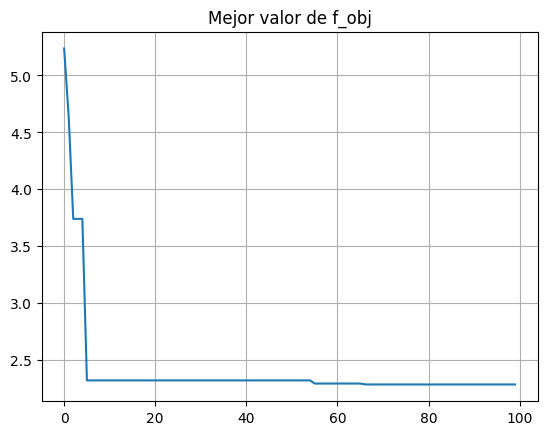

In [ ]:
# Gráfica del valor de la función objetivo de la mejor solución en cada generación.
plt.plot(np.arange(len(mejor_solucion)),mejor_solucion)
plt.title('Mejor valor de f_obj')
plt.grid()
plt.show()

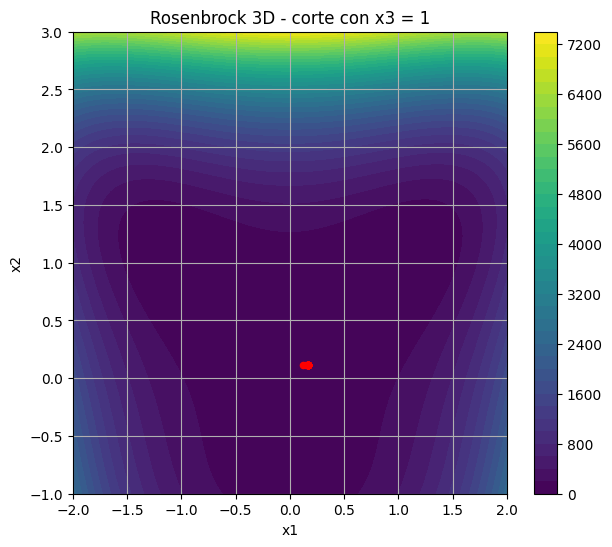

In [ ]:
# Corte 2D fijando x3 = 1
n_points = 100
X = np.linspace(-2, 2, n_points)
Y = np.linspace(-1, 3, n_points)
X, Y = np.meshgrid(X, Y)

x3_fijo = 1.0

Z = np.array([
    rosenbrock(np.array([X[i,j], Y[i,j], x3_fijo]))
    for i in range(n_points)
    for j in range(n_points)
]).reshape(n_points, n_points)

fig, ax = plt.subplots(figsize=(7,6))
cp = ax.contourf(X, Y, Z, levels=40)
plt.colorbar(cp)
ax.scatter(Poblacion[-1][:,0], Poblacion[-1][:,1], c='red', s=20)
ax.set_title('Rosenbrock 3D - corte con x3 = 1')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.grid()
plt.show()

### 2.3 Optimización la función Schwefel

A continuación se muestra la optimización de la función

$$f(x) = 418.9829 \cdot n - \sum_{i=1}^{n} x_i \sin(\sqrt{|x_i|})$$

In [ ]:
# Tipos
from numpy.typing import NDArray
from typing import Callable, TypedDict
type Array = NDArray[np.float64]

In [ ]:
def schwefel(x: Array):
    d = len(x)
    return 418.9829*d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

#### 2.3.1 Caso bimodal (Dimensión 2)

A continuación se muestra la optimización de la función para dos dimensiones: $$f(x,y) = 418.9829 \cdot 2 - \left[ x \sin(\sqrt{|x|}) + y \sin(\sqrt{|y|}) \right]$$

In [ ]:
LB = np.array([-500]*2)
UB = np.array([500]*2)

In [ ]:
# Paso intermedio para graficar las curvas de nivel de la función:
n_points = 50
X = np.linspace(-500, 500, n_points)
Y = np.linspace(-500, 500, n_points)
X, Y = np.meshgrid(X,Y)

In [ ]:
Z = np.array([
    schwefel(np.array([X[i,j], Y[i,j]]))
    for i in range(n_points)
    for j in range(n_points)
]).reshape(n_points, n_points)

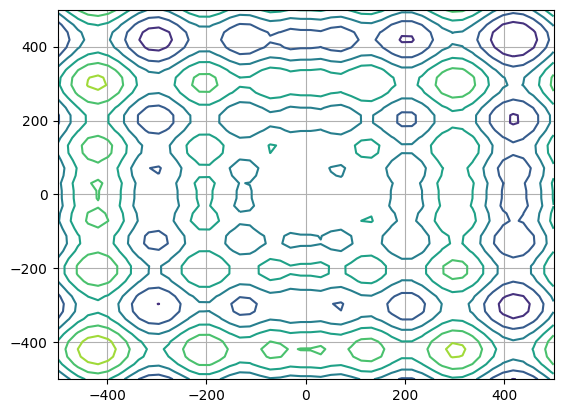

In [ ]:
# Gráfica de las curvas de nivel de la función:
fig, ax = plt.subplots()
ax.contour(X,Y,Z)
plt.xlim([-500,500])
plt.ylim([-500,500])
plt.grid()
plt.show()

Optimización de la función

In [ ]:
LB = np.array([-500, -500])
UB = np.array([500, 500])

Poblacion, mejor_solucion = mi_algoritmo_evolutivo(
    f_obj=schwefel,
    d=2,
    LB=LB,
    UB=UB,
    fr_elitismo=0.1,
    fr_mutacion=0.1,
    max_iter=100,
    semilla=2
)

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7,6))

ax.contour(X, Y, Z, levels=20)
scat = ax.scatter([], [], c='red', s=35)

ax.set_xlim([-500, 500])
ax.set_ylim([-500, 500])
ax.set_title("Evolución de la población - Schwefel")

def update(frame):
    data = Poblacion[frame]
    scat.set_offsets(data[:, :2])
    ax.set_title(f"Generación {frame}")
    return scat,

anim = FuncAnimation(fig, update, frames=len(Poblacion), interval=200)

# Exportar como MP4
anim.save("schwefel_animacion.mp4", writer="ffmpeg", fps=5, dpi=150)

# Opcional: mostrar en notebook
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

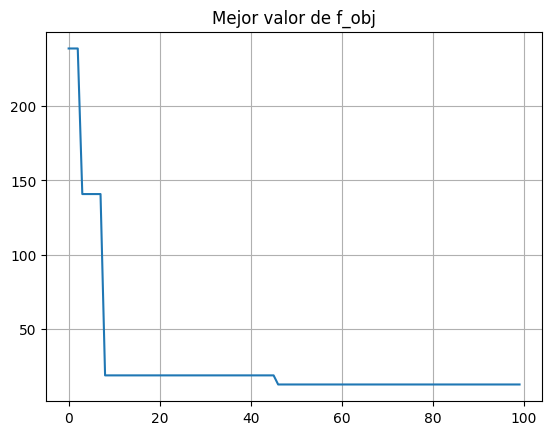

In [ ]:
# Gráfica del valor de la función objetivo de la mejor solución en cada generación.
plt.plot(np.arange(len(mejor_solucion)),mejor_solucion)
plt.title('Mejor valor de f_obj')
plt.grid()
plt.show()

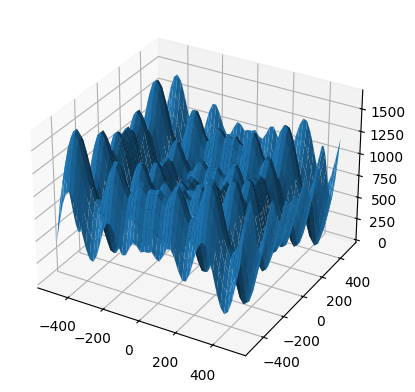

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X,Y,Z)
plt.show()

In [ ]:
# Gráfica del valor de la función objetivo de la mejor solución en cada generación.

"""
for j in range(100):
  fig, ax = plt.subplots()
  ax.contour(X,Y,Z)
  ax.scatter(Poblacion[j][:,0], Poblacion[j][:,1])
  plt.xlim([-1,1])
  plt.ylim([-1,1])
  plt.title('Generación ' + str(j))
  plt.show()

  """

"\nfor j in range(100):\n  fig, ax = plt.subplots()\n  ax.contour(X,Y,Z)\n  ax.scatter(Poblacion[j][:,0], Poblacion[j][:,1])\n  plt.xlim([-1,1])\n  plt.ylim([-1,1])\n  plt.title('Generación ' + str(j))\n  plt.show()\n\n  "

#### 2.3.2 Caso bimodal (Dimensión 3)

A continuación se muestra la optimización de la función para tres dimensiones: $$f(x,y,z) = 418.9829 \cdot 3 - \left[ x \sin(\sqrt{|x|}) + y \sin(\sqrt{|y|}) + z \sin(\sqrt{|z|}) \right]$$

Optimización de la función

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def schwefel(x):
    d = len(x)
    return 418.9829*d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

# Optimización 3D
LB = np.array([-500.0, -500.0, -500.0])
UB = np.array([ 500.0,  500.0,  500.0])

Poblacion, mejor_solucion = mi_algoritmo_evolutivo(
    f_obj=schwefel,
    d=3,
    LB=LB,
    UB=UB,
    fr_elitismo=0.1,
    max_iter=100,
    semilla=2
)



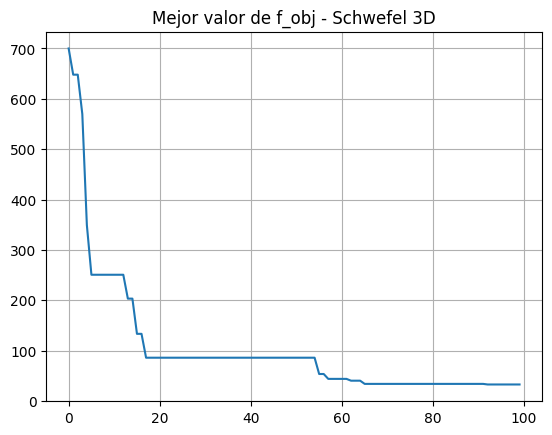

In [ ]:
# Evolución del mejor valor
plt.plot(np.arange(len(mejor_solucion)), mejor_solucion)
plt.title("Mejor valor de f_obj - Schwefel 3D")
plt.grid()
plt.show()

# Corte 2D fijando x3
n_points = 100
X = np.linspace(-500, 500, n_points)
Y = np.linspace(-500, 500, n_points)
X, Y = np.meshgrid(X, Y)

x3_fijo = 420.9687

Z = np.array([
    schwefel(np.array([X[i, j], Y[i, j], x3_fijo]))
    for i in range(n_points)
    for j in range(n_points)
]).reshape(n_points, n_points)

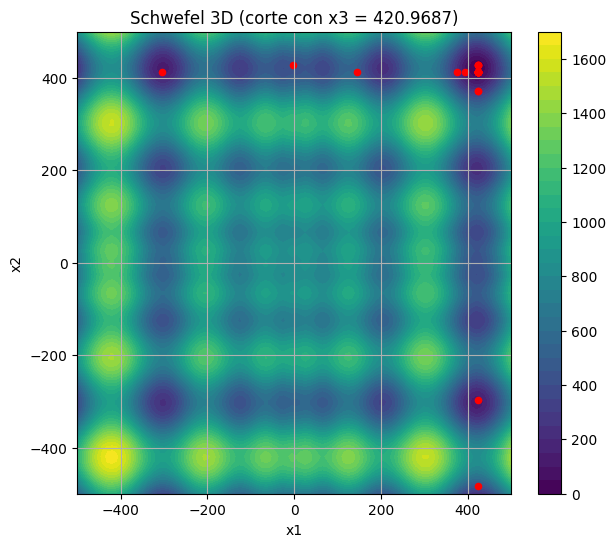

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
cp = ax.contourf(X, Y, Z, levels=40)
plt.colorbar(cp)

ax.scatter(Poblacion[-1][:, 0], Poblacion[-1][:, 1], c='red', s=20)

ax.set_title(f"Schwefel 3D (corte con x3 = {x3_fijo})")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.grid()
plt.show()

Instrucciones del trabajo 1 de 2 que presentarán los estudiantes que retoman el curso después de la anormalidad académica.

Parte 1: optimización numérica
Considere las siguientes funciones de prueba:
- Función de Rosenbrock
- Función de Rastrigin
- Función de Schwefel.
- Función de Griewank
- Función Goldstein-Price
- Función de las seis jorobas de camello
1. Optimice las funciones en dos y tres dimensiones usando un método de descenso por gradiente con condición inicial aleatoria. Repita este proceso n=100, 500  y 1000 y obtenga los histogramas de la solución final en cada caso y del número de evaluaciones de la función objetivo.
2. Optimice las funciones en dos y tres dimensiones usando: a) algoritmos evolutivos, b) optimización de partículas y c) evolución diferencial.
3. Represente con un gif animado o un video el proceso de optimización de descenso por gradiente y el proceso usando el método heurístico (para un solo caso)

Discuta
¿Qué aportaron los métodos de descenso por gradiente y qué aportaron los métodos heurísticos? Para responder a esta pregunta considere el valor final de la función objetivo y el número de evaluaciones de la función objetivo. Para responder a esta pregunta es posible que se requiera hacer varias corridas de los algoritmos.